Data loading, pre-processing and representation
---



In [ ]:
#adding libraries
from sklearn import linear_model  
from sklearn.linear_model import LinearRegression  
import csv          
import requests     
import numpy as np  
import pandas as pd 
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from sklearn import metrics

In [ ]:
#accessing the dataset file stored in the Google drive
from google.colab import drive
drive.mount('/content/gdrive')
import os
os.chdir("/content/gdrive/MyDrive/Colab Notebooks")
!ls
#Reading the dataset file
my_dataset = pd.read_csv('penguins_size.csv')
#Representing datatypes of the dataset columns
print(my_dataset.dtypes) 

Mounted at /content/gdrive
 1_Mājas_Darbs_
 2_Mājas_Darbs
 2_Mājas_darbs_papildinājums
 3_Mājas_Darbs
 4_Mājas_darbs
 5_Mājas_darbs
'Copy of 01-data-exploration.ipynb'
 dataset_painted.csv
 Demonstration_Regression
 iris.csv
 MD1_NTNU
 MD2_NTNU
 nt_vizualizacija
 Patstavigais_2_nodarbiba
 Patstavigais_darbs_07_04_2022
 penguins_size.csv
 RealEstate.csv
 singles.txt
 TemperatureAnomaly.csv
 Temperatures.csv
 Unsupervised_demonstration
 visualize-neural-network
 wine.txt
'Копия блокнота "1_Mājas_Darbs_"'
'Копия блокнота "Bonuss_P2_3_Regresija_un_Klasterizācija.ipynb"'
'Копия блокнота "P1_IevadsColabNotebook.ipynb"'
'Копия блокнота "P2_LinearaRegresija_Uzdevumi.ipynb"'
'Копия блокнота "P5_NeironuTIkli_Uzdevumi.ipynb"'
species               object
island                object
culmen_length_mm     float64
culmen_depth_mm      float64
flipper_length_mm    float64
body_mass_g          float64
sex                   object
dtype: object


In [ ]:
#Since categorical attributes are specified as "object", this is changed to "category"
my_dataset["species"] = my_dataset["species"].astype('category')
my_dataset["island"] = my_dataset["island"].astype('category')
my_dataset["sex"] = my_dataset["sex"].astype('category')
#New columns are created for categorical attributes and their values are converted to numeric values
my_dataset["species_cat"] = my_dataset["species"].cat.codes
my_dataset["island_cat"] = my_dataset["island"].cat.codes
my_dataset["sex_cat"] = my_dataset["sex"].cat.codes
#Representing datatypes of the dataset columns
print(my_dataset.dtypes) 

species              category
island               category
culmen_length_mm      float64
culmen_depth_mm       float64
flipper_length_mm     float64
body_mass_g           float64
sex                  category
species_cat              int8
island_cat               int8
sex_cat                  int8
dtype: object


In [ ]:
#Columns of the category type are discarded for further work
my_reduced_dataset = my_dataset[["culmen_length_mm","culmen_depth_mm","flipper_length_mm","body_mass_g","species_cat","island_cat","sex_cat"]]
#Column names are displayed
print(my_reduced_dataset.columns)
#The first 7 data objects in the dataset are displayed
print(my_reduced_dataset.head(7))
#Dataset data are displayed
print(my_reduced_dataset.describe())
print(my_reduced_dataset.info()) 

Index(['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm',
       'body_mass_g', 'species_cat', 'island_cat', 'sex_cat'],
      dtype='object')
   culmen_length_mm  culmen_depth_mm  flipper_length_mm  body_mass_g  \
0              39.1             18.7              181.0       3750.0   
1              39.5             17.4              186.0       3800.0   
2              40.3             18.0              195.0       3250.0   
3               NaN              NaN                NaN          NaN   
4              36.7             19.3              193.0       3450.0   
5              39.3             20.6              190.0       3650.0   
6              38.9             17.8              181.0       3625.0   

   species_cat  island_cat  sex_cat  
0            0           2        2  
1            0           2        1  
2            0           2        1  
3            0           2       -1  
4            0           2        1  
5            0           2        2  
6    

You can see above that there are two data objects in the dataset with missing values for the attributes "culmen_length_mm", "culmen_depth_mm", "flipper_length_mm", "body_mass_g". To obtain the values, we replace the missing values by the mean value of the attribute


In [ ]:
#Replacing missing values with average values
my_working_dataset=my_reduced_dataset.copy()
my_working_dataset['culmen_length_mm']=my_working_dataset['culmen_length_mm'].fillna(my_working_dataset['culmen_length_mm'].mean())
my_working_dataset['culmen_depth_mm']=my_working_dataset['culmen_depth_mm'].fillna(my_working_dataset['culmen_depth_mm'].mean())
my_working_dataset['flipper_length_mm']=my_working_dataset['flipper_length_mm'].fillna(my_working_dataset['flipper_length_mm'].mean())
my_working_dataset['body_mass_g']=my_working_dataset['body_mass_g'].fillna(my_working_dataset['body_mass_g'].mean())
#Dataset data are displayed
print(my_working_dataset.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   culmen_length_mm   344 non-null    float64
 1   culmen_depth_mm    344 non-null    float64
 2   flipper_length_mm  344 non-null    float64
 3   body_mass_g        344 non-null    float64
 4   species_cat        344 non-null    int8   
 5   island_cat         344 non-null    int8   
 6   sex_cat            344 non-null    int8   
dtypes: float64(4), int8(3)
memory usage: 11.9 KB
None


In [ ]:
#For attributes of categorical type, the values are checked against possible values
print(my_working_dataset['island_cat'].value_counts())
print(my_working_dataset['species_cat'].value_counts())
print(my_working_dataset['sex_cat'].value_counts())

0    168
1    124
2     52
Name: island_cat, dtype: int64
0    152
2    124
1     68
Name: species_cat, dtype: int64
 2    168
 1    165
-1     10
 0      1
Name: sex_cat, dtype: int64


### ***Analysis of categorical values***
Above you can see that there is something wrong with the values of the sex attribute (sex_cat), because two unknown values appear, even though this attribute should only have the values Male and Female

In [ ]:
#Unknown values of the attribute "sex_cat" are marked with 0 to separate all unknown values in this way
my_working_dataset["sex_cat"].mask(my_working_dataset["sex_cat"] == -1, 0, inplace=True)
print(my_working_dataset['sex_cat'].value_counts())

2    168
1    165
0     11
Name: sex_cat, dtype: int64


In [ ]:
#Data normalisation is applied for four attributes to make the data more consistent
my_working_dataset['culmen_length_mm']=(my_working_dataset['culmen_length_mm']-my_working_dataset['culmen_length_mm'].min())/(my_working_dataset['culmen_length_mm'].max()-my_working_dataset['culmen_length_mm'].min())
my_working_dataset['culmen_depth_mm']=(my_working_dataset['culmen_depth_mm']-my_working_dataset['culmen_depth_mm'].min())/(my_working_dataset['culmen_depth_mm'].max()-my_working_dataset['culmen_depth_mm'].min())
my_working_dataset['flipper_length_mm']=(my_working_dataset['flipper_length_mm']-my_working_dataset['flipper_length_mm'].min())/(my_working_dataset['flipper_length_mm'].max()-my_working_dataset['flipper_length_mm'].min())
my_working_dataset['body_mass_g']=(my_working_dataset['body_mass_g']-my_working_dataset['body_mass_g'].min())/(my_working_dataset['body_mass_g'].max()-my_working_dataset['body_mass_g'].min())
print(my_working_dataset.head(10))
print(my_working_dataset.describe())

   culmen_length_mm  culmen_depth_mm  flipper_length_mm  body_mass_g  \
0          0.254545         0.666667           0.152542     0.291667   
1          0.269091         0.511905           0.237288     0.305556   
2          0.298182         0.583333           0.389831     0.152778   
3          0.429888         0.482282           0.490088     0.417154   
4          0.167273         0.738095           0.355932     0.208333   
5          0.261818         0.892857           0.305085     0.263889   
6          0.247273         0.559524           0.152542     0.256944   
7          0.258182         0.773810           0.389831     0.548611   
8          0.072727         0.595238           0.355932     0.215278   
9          0.360000         0.845238           0.305085     0.430556   

   species_cat  island_cat  sex_cat  
0            0           2        2  
1            0           2        1  
2            0           2        1  
3            0           2        0  
4            0   

#Data visualisation
---

###Representing values

<AxesSubplot:>

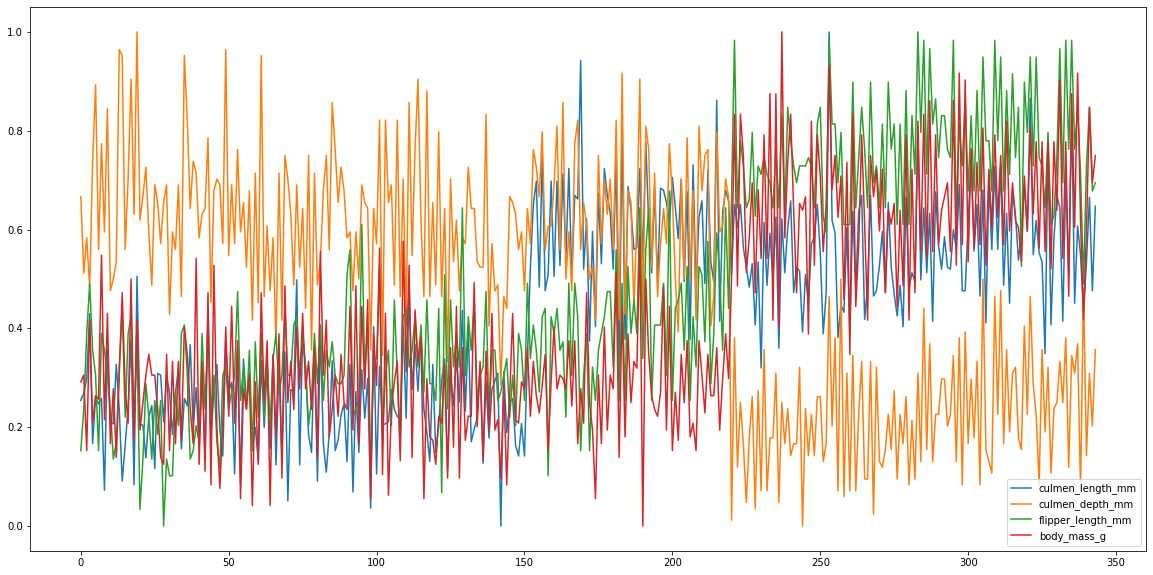

In [ ]:
#Only attributes with numeric values on a continuous scale are selected for value visualisation
data_for_visualisation = my_working_dataset[["culmen_length_mm","culmen_depth_mm","flipper_length_mm","body_mass_g"]]
#Representing values
data_for_visualisation.plot(figsize=(20,10))

###***Analysis of value representation***

Analysis of value representation
The analysis allows making the following conclusions:
- when the culmen depth is greater than 0.4, the culmen length, the flipper length and the body mass decrease (values <0.4)
- when the culmen depth is around 0.5, the culmen length, the flipper length and the body mass are also around the same value (everything merges together)
- when the culmen depth is less than 0.4, the culmen length, the flipper length and the body mass (values >0.4)
- in general, the culmen length, the flipper length and the body mass change together

###Value distributions

array([[<AxesSubplot:title={'center':'culmen_length_mm'}>,
        <AxesSubplot:title={'center':'culmen_depth_mm'}>,
        <AxesSubplot:title={'center':'flipper_length_mm'}>],
       [<AxesSubplot:title={'center':'body_mass_g'}>,
        <AxesSubplot:title={'center':'species_cat'}>,
        <AxesSubplot:title={'center':'island_cat'}>],
       [<AxesSubplot:title={'center':'sex_cat'}>, <AxesSubplot:>,
        <AxesSubplot:>]], dtype=object)

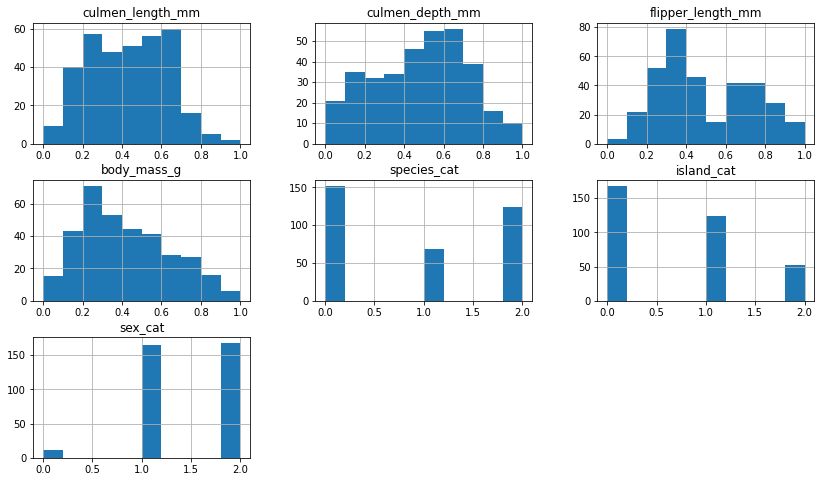

In [ ]:
#Displaying histograms
my_working_dataset.hist(figsize=(14,8))

###***Histogram analysis***

The histograms show that one of the penguin species is under-represented. This means that the classes available in the dataset are not balanced. The same can be observed for the islands from which the penguins originate: one of them is less represented. In addition, there are more penguins with lower body mass and more penguins with the longest culmen and more penguins with the shortest flipper length in the dataset.

###Feature pairplots

Text(0.5, 0.98, 'Feature pairplot')

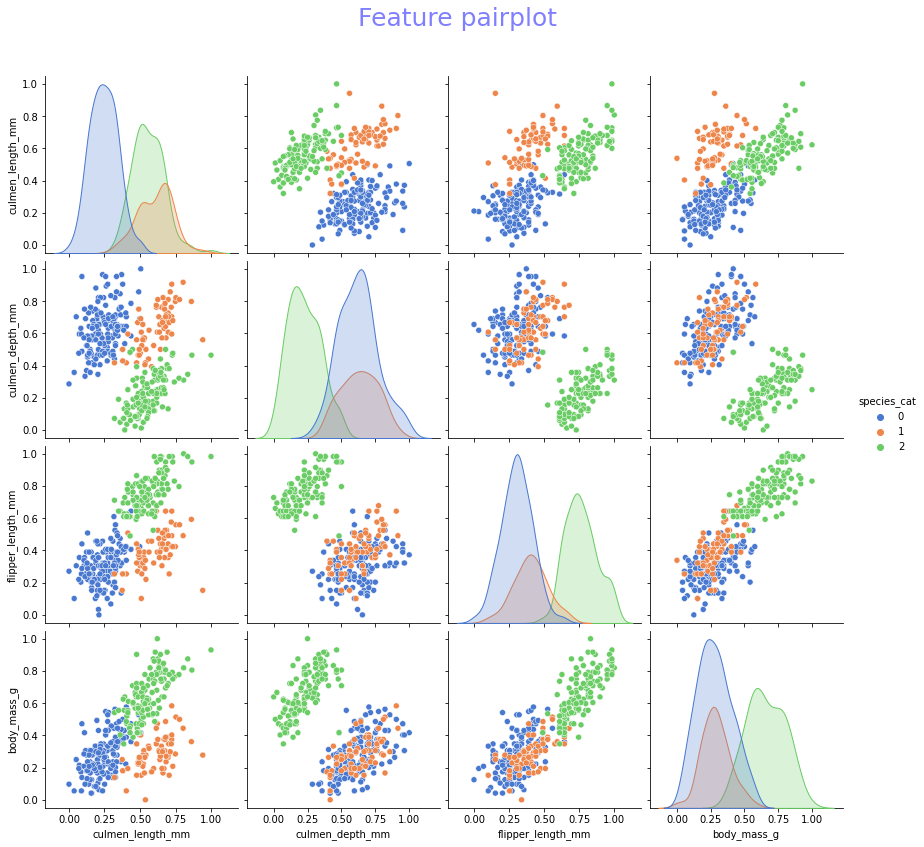

In [ ]:
#Creating a pairplot
my_pairplot = sns.pairplot(my_working_dataset,hue='species_cat',palette="muted",height=3,vars=['culmen_length_mm','culmen_depth_mm','flipper_length_mm', 'body_mass_g'],kind='scatter')
#Extra space to display the title correctly
plt.subplots_adjust(top=0.9)
#Giving a title of the pairplot
my_pairplot.fig.suptitle('Feature pairplot',fontsize=25,color='b',alpha=0.5)

###***Pairplot analysis***
We analyse features relationships based on penguin species. The pairplots suggest that such pairs of features provide reasonably good class separation:
* "culmen_length_mm" and "culmen_depth_mm" 
* "culmen_length_mm" and "flipper_lenght_mm"
and can be used in a classification task.

However, the following pairs of features do not provide good class separation:
* "culmen_length_mm" and "body_mass_g": blue data objects partially merge with green data objects and only orange data objects are well separable
* "culmen_depth_mm" and "flipper_length_mm": blue data objects merge with orange data objects, only green data objects are well separable
* "culmen_depth_mm" and "body_mass_g": blue data objects merge with orange data objects and only green data objects are well separable
* "flipper_length_mm" and "body_mass_g": blue data objects merge with orange data objects and only green data objects are well separable

###Feature correlations

<AxesSubplot:>

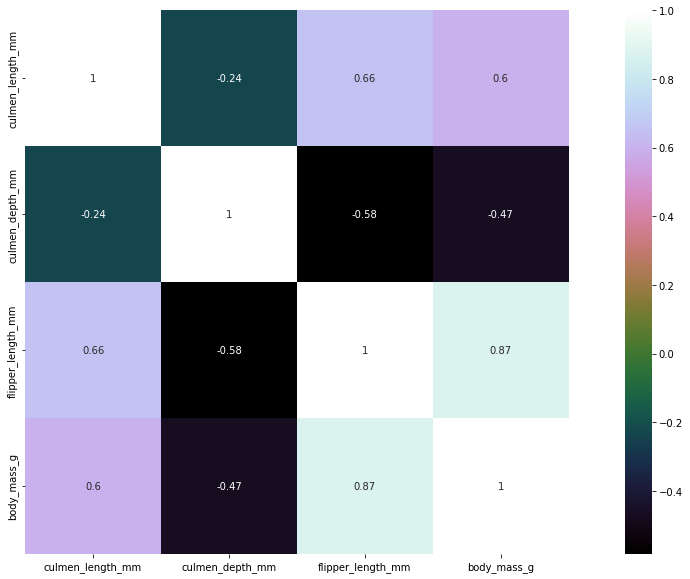

In [ ]:
#A correlation matrix is created, showing the correlation coefficient for the numeric features
my_correlation_matrix=data_for_visualisation.corr(method='pearson')
plt.figure(figsize=(20,10))
sns.heatmap(my_correlation_matrix,vmax=1,square=True,annot=True,cmap='cubehelix')

###***Correlation matrix analysis***
The correlation matrix analysis shows that:
* there is a weak negative correlation between the features "culmen_length_mm" and "culmen_depth_mm"
* the feature "culmen_length_mm" has an average positive correlation with the features "flipper_length_mm" and "body_mass_g"
* the feature "culmen_depth_mm" has an average negative correlation with the features "flipper_length_mm" and "body_mass_g"
* there is a high positive correlation between the features "flipper_length_mm" and "body_mass_g"

Thus, for the last two features, one can anticipate a multicollinearity problem that may complicate the interpretation of the linear regression results, so that it would not be desirable to include these features in the further analysis.

#One factor linear regression model
---
Analysis questions:
* How does culmen length (culmen_length_mm) affect penguin body mass (body_mass_g)?



Coefficient: 
 [0.65269696]
Intercept: 
 0.13711954612821647


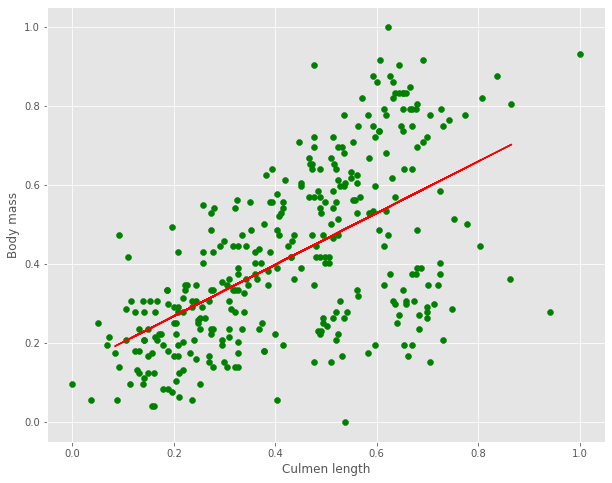

0.36774647951479345


In [ ]:
from sklearn.model_selection import train_test_split
#obtain a datset containing only one feature of interest
my_working_dataset_1_feature = my_working_dataset[["culmen_length_mm"]]
#ontaining tagte values
target = my_working_dataset['body_mass_g']
#setting the size of the train and test datasets (70% for training data, 30% - for test data)
training_proportion = 0.7
#splitting the dataset into test and train sets using a random 70:30 split
X_train, X_test, y_train, y_test = train_test_split(my_working_dataset_1_feature, target, test_size=1.0 - training_proportion, random_state=42)
model_culmen_length = LinearRegression(fit_intercept=True)        #Initialisation of the regression model
model_culmen_length.fit(X_train,y_train)        #Training the regression model using the data on culmen lenght available in the train dataset
print('Coefficient: \n', model_culmen_length.coef_)               #Displaying the model weights
print('Intercept: \n', model_culmen_length.intercept_)            #Displaying the bias coefficient of the model
# =================== Apply the model to all values of the culmen length in the dataset======================
y_test_pred = model_culmen_length.predict(X_test) #Obtaining predictions with the trained model
#Graphical representation of the model
matplotlib.style.use('ggplot')
plt.figure(1, (10,8))  #Figure with the size of 10 x 8   
plt.scatter(my_working_dataset['culmen_length_mm'],my_working_dataset['body_mass_g'], color = 'green')   #Displaying the dependence of body mass on the culmen length 
plt.plot(X_test,y_test_pred, color="red")        #Displaying the model
plt.xlabel("Culmen length")        # Title of X-axis
plt.ylabel("Body mass")          #Title of y-axis
plt.show()
#dislaying the coefficient of determination
print(model_culmen_length.score(X_test,y_test))

# Multivariate Linear Regression Model
---
Analysis questions:
* How does culmen length and culmen depth affect penguin body mass (body_mass_g)?

In [ ]:
#obtain a datset containing only one feature of interest
my_working_dataset_2_features = my_working_dataset[["culmen_length_mm", "culmen_depth_mm"]]
#ontaining tagte values
target_2 = my_working_dataset['body_mass_g']
#setting the size of the train and test datasets (70% for training data, 30% - for test data)
training_proportion = 0.7
#splitting the dataset into test and train sets using a random 70:30 split
X_train, X_test, y_train, y_test = train_test_split(my_working_dataset_2_features, target_2, test_size=1.0 - training_proportion, random_state=42)
model_multivariate = LinearRegression(fit_intercept=True)        #Initialisation of the regression model
model_multivariate.fit(X_train,y_train)        #Training the regression model using the data on culmen lenght available in the train dataset
print('Coefficient: \n', model_multivariate.coef_)               #Displaying the model weights
print('Intercept: \n', model_multivariate.intercept_)            #Displaying the bias coefficient of the model
# =================== Apply the model to all values of the culmen length in the dataset======================
y_test_pred = model_multivariate.predict(X_test) #Obtaining predictions with the trained model
#dislaying the coefficient of determination
print(model_multivariate.score(X_test,y_test))

Coefficient: 
 [ 0.55646685 -0.36152539]
Intercept: 
 0.35011519412205677
0.43024290437391766
